<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Spectre_synthetique_par_interpolation_Pickles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectre synthétique par interpolation Pickles (étoiles B / A)

Reconstruction d'un template de type spectral intermédiaire par interpolation
linéaire en indice de type entre deux spectres Pickles observés de **même classe
de luminosité**. Configuré ici pour **B5V** (réf. HD 43157) à partir de B3V et
B8V, mais réutilisable pour toute cible B ou A — voir la cellule *Garde-fous*.

Le `.dat` de sortie est écrit **au format exact des fichiers Pickles d'entrée** :
mêmes longueurs d'onde, deux colonnes, `%.4f %.8f`, fins de ligne CRLF, sans
en-tête — directement interchangeable avec le reste de ta base.

**Pourquoi l'interpolation Pickles plutôt qu'un modèle jouet ?** Les profils de
Balmer des spectres Pickles sont *observés* — largeur d'aile de Stark et
profondeur réelles. Une interpolation linéaire sur un intervalle de type modeste
préserve ces profils bien mieux qu'un continuum de corps noir décoré de raies
posées à la main.

**Limites (détaillées dans la cellule Garde-fous) :**
- Interpolation linéaire → suppose une variation ~monotone du spectre avec le type.
- Reste à **classe de luminosité fixe** (ne pas mélanger V / III / I).
- Ne pas enjamber le maximum des Balmer (A0–A2) ni la frontière B/A.
- Résultat *relatif*, normalisé à 1.0 à 5556 Å (convention Pickles).


## 1. Réglages

In [1]:
# --- Fichiers d'entrée (Pickles .dat : 2 colonnes  lambda[A]  flux) ---
FILE_LOW  = "p_b3v.dat"    # borne "bleue"  (type le plus précoce)
FILE_HIGH = "p_b8v.dat"    # borne "rouge"  (type le plus tardif)

# --- Indices de type spectral (echelle continue : B0..B9 = 0..9, A0..A9 = 10..19) ---
#     O5=-5  B0=0  B5=5  A0=10  A5=15  F0=20 ...
IDX_LOW    = 3.0   # B3V
IDX_HIGH   = 8.0   # B8V
IDX_TARGET = 5.0   # B5V  <-- la cible

# --- Normalisation (convention Pickles : flux = 1.0 a 5556 A) ---
LAM_NORM   = 5556.0     # A, point de normalisation
NORM_HALFWIN = 0.0      # A, demi-fenetre mediane ; 0 = point exact (compat Pickles)

# --- Sortie ---
OUT_DAT = "p_b5v.dat"                        # adapte le nom a ta cible
OUT_PNG = "p_b5v_check.png"
OUT_FMT = "%.4f %.8f"                         # format colonnes identique aux entrees
OUT_CRLF = True                              # fins de ligne Windows comme Pickles


## 1bis. Garde-fous — à lire avant de changer les bornes

Cette cellule **n'exécute aucun calcul lourd** : elle vérifie seulement que ta
configuration (IDX_LOW / IDX_HIGH / IDX_TARGET) reste dans le domaine où
l'interpolation linéaire est fiable, et t'imprime des avertissements sinon.

Rappels physiques encodés dans les tests :

- **Cible entre les bornes.** L'extrapolation (cible hors [low, high]) est
  bloquée : les raies varient trop pour être extrapolées linéairement.
- **Bornes rapprochées.** Un écart de plus de ~5 sous-types entre les bornes rend
  l'hypothèse de linéarité fragile → avertissement.
- **Maximum des Balmer (A0–A2 ≈ indices 10–12).** Les raies de Balmer culminent
  vers A0–A2 puis décroissent. Si tes deux bornes encadrent cette zone,
  l'interpolation **sous-estime** la profondeur des Balmer de la cible →
  avertissement. Prends des bornes du même côté du pic.
- **Frontière B/A (indice 10).** Franchir B→A fait apparaître les raies
  métalliques (Ca II K, raie G) et disparaître He I de façon non-linéaire →
  avertissement. Reste dans un même régime.
- **Classe de luminosité.** Ce notebook interpole en *type* à classe fixe. Ne
  l'utilise pas pour mélanger V / III / I (ça mêle Teff et log g sur un seul axe).
  Aucun test automatique ici — c'est à toi de prendre deux bornes de même classe.


In [2]:
def check_config(idx_lo, idx_hi, idx_tgt, max_span=5.0):
    lo, hi = min(idx_lo, idx_hi), max(idx_lo, idx_hi)
    warn = []

    # 1) cible dans l'intervalle (sinon on arrete : extrapolation)
    if not (lo <= idx_tgt <= hi):
        raise ValueError(
            f"Cible idx={idx_tgt} hors de l'intervalle [{lo}, {hi}] : "
            "extrapolation déconseillée. Choisis des bornes qui encadrent la cible.")

    # 2) ecart entre bornes
    span = hi - lo
    if span > max_span:
        warn.append(
            f"Bornes espacées de {span:.0f} sous-types (> {max_span:.0f}). "
            "L'hypothèse de linéarité s'affaiblit ; resserre si possible.")
    if span == 0:
        warn.append("Les deux bornes ont le même indice — rien à interpoler.")

    # 3) maximum des Balmer A0-A2 (indices ~10-12) enjambe par les bornes
    BALMER_PEAK_LO, BALMER_PEAK_HI = 10.0, 12.0
    if lo < BALMER_PEAK_LO and hi > BALMER_PEAK_HI:
        warn.append(
            "Les bornes encadrent le maximum des raies de Balmer (A0–A2, idx 10–12). "
            "L'interpolation linéaire SOUS-ESTIMERA la profondeur des Balmer de la "
            "cible. Prends deux bornes du même côté du pic.")
    elif lo < BALMER_PEAK_HI and hi > BALMER_PEAK_LO and (lo < BALMER_PEAK_LO or hi > BALMER_PEAK_HI):
        warn.append(
            "Une borne est proche du maximum des Balmer (A0–A2). Vérifie visuellement "
            "que la profondeur des Balmer de la cible est plausible (cellule 6).")

    # 4) frontiere B/A (indice 10) franchie
    BA_BORDER = 10.0
    if lo < BA_BORDER < hi:
        warn.append(
            "Les bornes franchissent la frontière B/A (idx 10) : apparition des raies "
            "métalliques (Ca II K, raie G) et disparition de He I sont NON-linéaires. "
            "Reste dans un même régime (tout B, ou tout A).")

    # rapport
    def label(idx):
        cls = "OBAFGKM"[int(idx // 10) + 1] if idx >= -10 else "?"
        return f"{cls}{idx % 10:g}"
    print(f"Cible {label(idx_tgt)}  entre  {label(lo)} et {label(hi)}  "
          f"(indices {idx_tgt} in [{lo}, {hi}])")
    if warn:
        print("\n⚠ AVERTISSEMENTS :")
        for w in warn:
            print("  •", w)
        print("\nL'interpolation reste possible, mais le template peut être trompeur "
              "aux endroits signalés. Vérifie la cellule de contrôle visuel (6).")
    else:
        print("✓ Configuration dans le domaine sûr de l'interpolation linéaire.")
    return warn

_ = check_config(IDX_LOW, IDX_HIGH, IDX_TARGET)


Cible B5  entre  B3 et B8  (indices 5.0 in [3.0, 8.0])
✓ Configuration dans le domaine sûr de l'interpolation linéaire.


## 2. Upload des deux fichiers Pickles

Exécute la cellule et sélectionne tes deux `.dat`.
En local (Jupyter), saute cette cellule et place les fichiers à côté du notebook.

In [3]:
try:
    from google.colab import files
    up = files.upload()
    print("Fichiers reçus :", list(up.keys()))
except ModuleNotFoundError:
    print("Hors Colab : assure-toi que", FILE_LOW, "et", FILE_HIGH, "sont dans le dossier courant.")


Saving p_b3v.dat to p_b3v.dat
Saving p_b8v.dat to p_b8v.dat
Fichiers reçus : ['p_b3v.dat', 'p_b8v.dat']


## 3. Lecture robuste des .dat Pickles

In [4]:
import numpy as np

def read_pickles(path):
    """Lit un .dat Pickles (2 col: lambda flux). Tolère commentaires #/; , CRLF, virgule décimale."""
    lam, flx = [], []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if not s or s[0] in "#;":
                continue
            parts = s.replace(",", " ").split()
            try:
                l, y = float(parts[0]), float(parts[1])
            except (ValueError, IndexError):
                continue
            lam.append(l); flx.append(y)
    lam = np.asarray(lam); flx = np.asarray(flx)
    order = np.argsort(lam)
    return lam[order], flx[order]

lam_lo, fl_lo = read_pickles(FILE_LOW)
lam_hi, fl_hi = read_pickles(FILE_HIGH)
print(f"{FILE_LOW}:  {lam_lo.size} pts, {lam_lo.min():.0f}-{lam_lo.max():.0f} A")
print(f"{FILE_HIGH}: {lam_hi.size} pts, {lam_hi.min():.0f}-{lam_hi.max():.0f} A")


p_b3v.dat:  1895 pts, 1150-10620 A
p_b8v.dat: 1895 pts, 1150-10620 A


## 4. Grille de sortie + normalisation

Si les deux fichiers partagent déjà la même grille λ (cas des spectres Pickles
standard), on la **conserve telle quelle** — le `.dat` de sortie aura donc
exactement les mêmes longueurs d'onde que les entrées. Sinon, on ré-échantillonne
le second sur la grille du premier.

Normalisation **au continuum** à `LAM_NORM` (jamais au flux total).

In [5]:
def norm_at(lam, flx, l0, half):
    """Normalise a 1.0 : point exact si half<=0, sinon mediane sur +/- half."""
    if half <= 0:
        j = int(np.argmin(np.abs(lam - l0)))
        return flx / flx[j]
    m = np.abs(lam - l0) <= half
    if not m.any():
        raise ValueError(f"Aucun point autour de {l0} A pour normaliser.")
    return flx / np.median(flx[m])

same_grid = (lam_lo.size == lam_hi.size) and np.allclose(lam_lo, lam_hi)
if same_grid:
    grid = lam_lo
    r_lo, r_hi = fl_lo.copy(), fl_hi.copy()
    print(f"Grilles identiques -> grille conservee ({grid.size} pts, {grid.min():.0f}-{grid.max():.0f} A)")
else:
    grid = lam_lo
    r_lo = fl_lo.copy()
    r_hi = np.interp(grid, lam_hi, fl_hi)
    print(f"Grilles differentes -> {FILE_HIGH} reechantillonne sur la grille de {FILE_LOW}")

r_lo = norm_at(grid, r_lo, LAM_NORM, NORM_HALFWIN)
r_hi = norm_at(grid, r_hi, LAM_NORM, NORM_HALFWIN)


Grilles identiques -> grille conservee (1895 pts, 1150-10620 A)


## 5. Interpolation linéaire en indice de type

$$F_{tgt}(\lambda) = w_{lo}\,F_{lo}(\lambda) + w_{hi}\,F_{hi}(\lambda),
\qquad w_{hi}=\frac{idx_{target}-idx_{lo}}{idx_{hi}-idx_{lo}},\;\; w_{lo}=1-w_{hi}$$

Pour B5V entre B3V/B8V : $w_{hi}=(5-3)/(8-3)=0.4$, $w_{lo}=0.6$ — B5 est plus
proche de B3 que de B8, donc le B3V pèse davantage.

In [6]:
w_hi = (IDX_TARGET - IDX_LOW) / (IDX_HIGH - IDX_LOW)
w_lo = 1.0 - w_hi
assert 0.0 <= w_hi <= 1.0, "Cible hors de l'intervalle [low, high] : extrapolation déconseillée."
print(f"Poids : w({FILE_LOW})={w_lo:.3f}   w({FILE_HIGH})={w_hi:.3f}")

flux_tgt = w_lo * r_lo + w_hi * r_hi
flux_tgt = norm_at(grid, flux_tgt, LAM_NORM, NORM_HALFWIN)   # re-cale a 1.0 @LAM_NORM

j = int(np.argmin(np.abs(grid - LAM_NORM)))
print(f"@ {LAM_NORM:.0f} A = {flux_tgt[j]:.4f}  (doit valoir 1.0000)")
for l0, nm in [(6562.8,"Ha"),(4861.3,"Hb"),(4340.5,"Hg")]:
    k = int(np.argmin(np.abs(grid - l0)))
    print(f"@{nm:3s}: lo={r_lo[k]:.3f}  tgt={flux_tgt[k]:.3f}  hi={r_hi[k]:.3f}")


Poids : w(p_b3v.dat)=0.600   w(p_b8v.dat)=0.400
@ 5556 A = 1.0000  (doit valoir 1.0000)
@Ha : lo=0.425  tgt=0.445  hi=0.475
@Hb : lo=1.073  tgt=1.101  hi=1.144
@Hg : lo=1.488  tgt=1.503  hi=1.525


## 6. Contrôle visuel

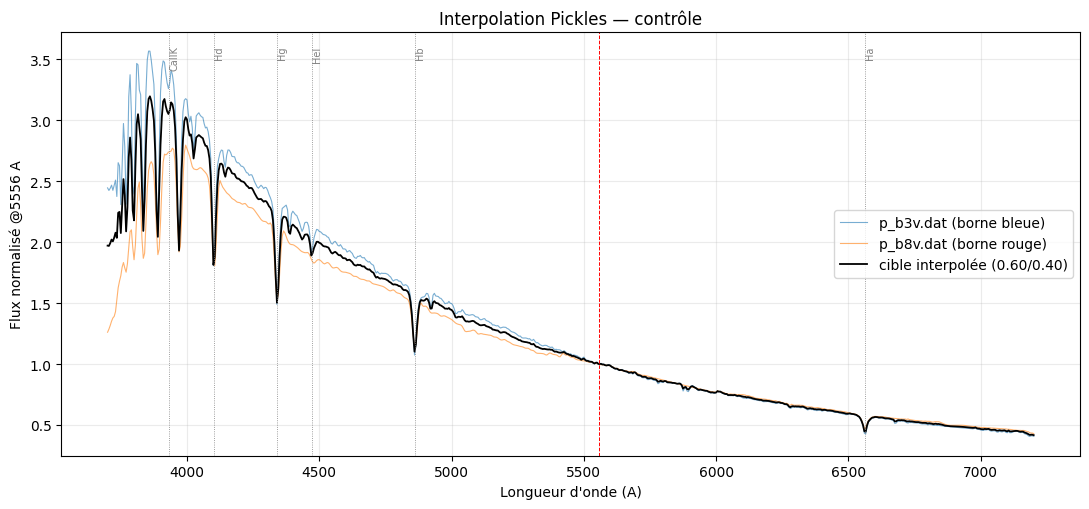

In [7]:
import matplotlib.pyplot as plt

m = (grid >= 3700) & (grid <= 7200)
fig, ax = plt.subplots(figsize=(11,5.2))
ax.plot(grid[m], r_lo[m],    lw=0.8, alpha=0.6, label=f"{FILE_LOW} (borne bleue)")
ax.plot(grid[m], r_hi[m],    lw=0.8, alpha=0.6, label=f"{FILE_HIGH} (borne rouge)")
ax.plot(grid[m], flux_tgt[m], lw=1.3, color="k", label=f"cible interpolée ({w_lo:.2f}/{w_hi:.2f})")
for l0,name in [(6562.8,"Ha"),(4861.3,"Hb"),(4340.5,"Hg"),(4101.7,"Hd"),(4471.5,"HeI"),(3933.7,"CaIIK")]:
    ax.axvline(l0, color="grey", ls=":", lw=0.6)
    ax.text(l0, ax.get_ylim()[1]*0.97, name, rotation=90, va="top", fontsize=7, color="grey")
ax.axvline(LAM_NORM, color="red", ls="--", lw=0.7)
ax.set_xlabel("Longueur d'onde (A)"); ax.set_ylabel("Flux normalisé @%.0f A" % LAM_NORM)
ax.set_title("Interpolation Pickles — contrôle")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout()
plt.savefig(OUT_PNG, dpi=130); plt.show()


**Vérification.** La cible (noir) doit passer *entre* les deux bornes partout,
et le raccord au point de normalisation (rouge) doit être propre. Si un
avertissement Balmer a été émis en cellule 1bis, contrôle ici que la profondeur
des raies de Balmer de la cible reste plausible (pas anormalement faible).

## 7. Export au format Pickles

Écriture ligne par ligne pour reproduire exactement le format des entrées : deux
colonnes, `%.4f %.8f`, fins de ligne CRLF, aucun en-tête. La grille λ étant
conservée, le fichier est byte-compatible avec tes autres spectres Pickles.

In [8]:
newline = "\r\n" if OUT_CRLF else "\n"
with open(OUT_DAT, "w", newline="") as f:
    for l, y in zip(grid, flux_tgt):
        f.write((OUT_FMT % (l, y)) + newline)
print("Écrit :", OUT_DAT, f"({grid.size} lignes)  et  {OUT_PNG}")

# --- verification de compatibilite avec un fichier d'entree ---
chk_lam = np.loadtxt(FILE_LOW)[:, 0]
out_lam = np.loadtxt(OUT_DAT)[:, 0]
ok = chk_lam.shape == out_lam.shape and np.allclose(chk_lam, out_lam)
print("Grille lambda identique aux entrées :", ok)
with open(OUT_DAT, "rb") as f:
    head = f.readline()
print("Exemple ligne brute :", head)   # doit se terminer par b'...\r\n' si CRLF

try:
    from google.colab import files
    files.download(OUT_DAT); files.download(OUT_PNG)
except ModuleNotFoundError:
    pass


Écrit : p_b5v.dat (1895 lignes)  et  p_b5v_check.png
Grille lambda identique aux entrées : True
Exemple ligne brute : b'1150.0000 47.89830025\r\n'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>